In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt



base_dir = os.path.normpath("G:/.shortcut-targets-by-id/0B3ejcGO9fA5eYXlHMW9tekVERmc/JB labs documents/Updated_JB_documents_2019/JB LAB_Projects/biofilm_qtl/data/platereader")

#G:\.shortcut-targets-by-id\0B3ejcGO9fA5eYXlHMW9tekVERmc\JB labs documents\Updated_JB_documents_2019\JB LAB_Projects\biofilm_qtl\data\platereader
#20250604_jb22_srb11_mus7_rpl12

In [34]:
fname_base = '20250604_jb22_srb11_mus7_rpa12'
skiprows_param = 10

od_data = pd.read_csv(base_dir + os.sep + fname_base + '.csv', skiprows=skiprows_param, index_col=0)
od_data = od_data.drop(columns = ['Time'])
times_raw = list(od_data.columns)

times = []
for time in times_raw:
    timesp = time.split(' h ')
    hour = int(timesp[0])
    if timesp[1]=='': 
        min = 0
    else: 
        min = int(timesp[1].split(' min')[0])
    times.append(float(hour + min/60))

In [35]:
#Plot entire 96 well plate: 

fig, axarr = plt.subplots(8,12, figsize = (120,80), sharey=True, sharex = True)
for jj, row in enumerate('ABCDEFGH'):
    for kk, col in enumerate(range(1,13)): 
        ax = axarr[jj,kk]
        well = row + str(col).zfill(2)
        ax.plot(times, od_data.loc[well,:])
        ax.set_ylim(0,1.25)
        if col==1: 
            ax.set_ylabel(row)
        if row=='H': 
            ax.set_xlabel(str(col))

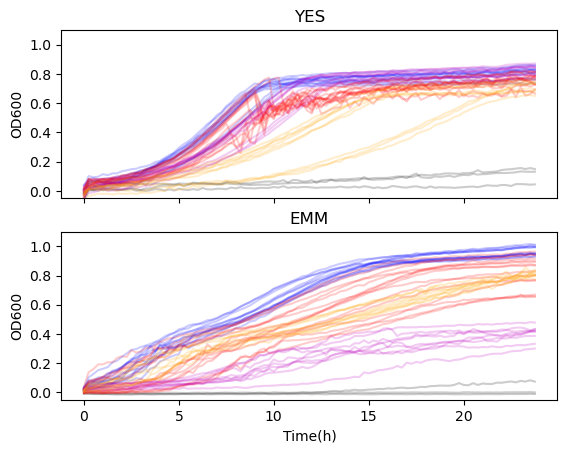

In [36]:
sample_map = pd.read_csv(base_dir + os.sep + '/' + fname_base + '_sample_map.csv')

fig, axarr = plt.subplots(2,1, sharex=True)

legend_labels = {'JB22': 'WT', 
            'control': 'media',
            'srb11del': u'srb11Δ', 
            'rpa12del': u'rpa12Δ',
            'mus7del': u'mus7Δ' 
            }

colormap = {'JB22': 'b', 
            'control': 'k',
            'srb11del': 'r', 
            'rpa12del': 'm',
            'mus7del': 'orange' 
            }

for jj, media in enumerate(['YES','EMM']): 

    #Get baseline value for each media
    row = list(sample_map[(sample_map['Media']==media) & (sample_map['Strain']=='control')]['Row'])[0]
    col = list(sample_map[(sample_map['Media']==media) & (sample_map['Strain']=='control')]['Column'])[0]

    well = row + str(col).zfill(2)
    blank_val = od_data.loc[well][1]  #Use 1 index as 0 index had an artifact because we didn't do the initial shake. 


    ax = axarr[jj]
    ax.set_title(media)
    if jj==1: 
        ax.set_xlabel('Time(h)')
    ax.set_ylabel('OD600')
    ax.set_ylim([-0.05, 1.1])
    for strain in colormap.keys():
        sample_map_media_strain = sample_map[(sample_map['Media']==media) & (sample_map['Strain']==strain)]
        for row, col in zip(sample_map_media_strain['Row'], sample_map_media_strain['Column']):
            well = row + str(col).zfill(2)
            ax.plot(times, od_data.loc[well,:]-blank_val, c = colormap[strain], alpha = 0.2, label = legend_labels[strain])

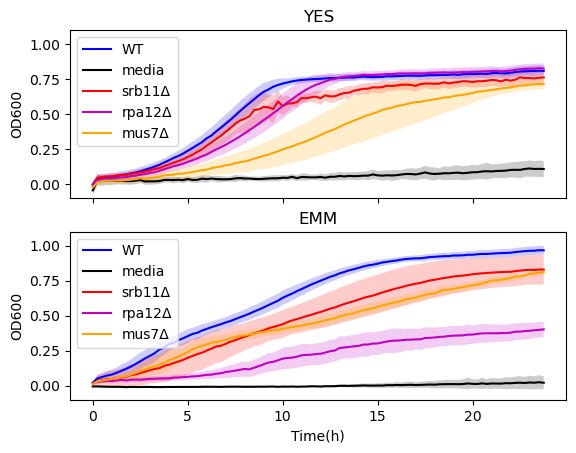

In [37]:
#Plot mean curves
fig, axarr = plt.subplots(2,1, sharex=True)

legend_labels = {'JB22': 'WT', 
            'control': 'media',
            'srb11del': u'srb11Δ', 
            'rpa12del': u'rpa12Δ',
            'mus7del': u'mus7Δ' 
            }

colormap = {'JB22': 'b', 
            'control': 'k',
            'srb11del': 'r', 
            'rpa12del': 'm',
            'mus7del': 'orange' 
            }

for jj, media in enumerate(['YES','EMM']):
    #Get baseline value for each media
    row = list(sample_map[(sample_map['Media']==media) & (sample_map['Strain']=='control')]['Row'])[0]
    col = list(sample_map[(sample_map['Media']==media) & (sample_map['Strain']=='control')]['Column'])[0]

    well = row + str(col).zfill(2)
    blank_val = od_data.loc[well][1]  #Use 1 index as 0 index had an artifact because we didn't do the initial shake. 


    ax = axarr[jj]
    ax.set_title(media)
    if jj==1: 
        ax.set_xlabel('Time(h)')
    ax.set_ylabel('OD600')
    ax.set_ylim([-0.1, 1.1])

    well_lists = dict(zip(colormap.keys(), [[] for jj in range(len(colormap.keys()))]))  #List to store well names for various conditions

    for strain in colormap.keys():
        sample_map_media_strain = sample_map[(sample_map['Media']==media) & (sample_map['Strain']==strain)]
        for row, col in zip(sample_map_media_strain['Row'], sample_map_media_strain['Column']):
            well = row + str(col).zfill(2)
            well_lists[strain].append(well)      
            
    
        mean = (od_data.loc[well_lists[strain],:]-blank_val).mean()
        std = (od_data.loc[well_lists[strain],:]-blank_val).std()
        ax.plot(times, mean, c = colormap[strain], label = legend_labels[strain])
        ax.fill_between(times, mean - std, mean + std, facecolor=colormap[strain], alpha=0.2)
    ax.legend()

    



# #plot edge vs middle
# fig, axarr = plt.subplots(2,1, sharex=True)

# colormap = {'JB22': 'r', 
#             'JB22_edge': 'grey',
#             'Control': 'b', 
#             'Control_edge': 'k'
#             }

# for jj, media in enumerate(['YES','EMM']): 
#     ax = axarr[jj]
#     ax.set_title(media)
#     if jj==1: 
#         ax.set_xlabel('Time(h)')
#     ax.set_ylabel('OD600')
#     ax.set_ylim([0, 1.25])

#     well_lists = {'JB22': [], 
#             'JB22_edge': [],
#             'Control': [], 
#             'Control_edge': []
#             }

#     for strain in ['JB22', 'Control']:  
#         sample_map_media_strain = sample_map[(sample_map['Media']==media) & (sample_map['Strain']==strain)]
        
#         for row, col in zip(sample_map_media_strain['Row'], sample_map_media_strain['Column']):  # Extract wells 
#             if (row in {'A','H'}) | (col in {1,12}):  # Edge well
#                 well = row + str(col).zfill(2)          
#                 well_lists[strain + '_edge'].append(well)
                
#             else: 
#                 well = row + str(col).zfill(2)          
#                 well_lists[strain].append(well)
#                 #ax.plot(times, od_data.loc[well,:], c = colormap[strain], alpha = 0.2)
    
        
#         for edge in {'', '_edge'}: 
#             mean = od_data.loc[well_lists[strain + edge],:].mean()
#             std = od_data.loc[well_lists[strain + edge],:].std()
#             ax.plot(times, mean, c = colormap[strain + edge], label = strain + edge)
#             ax.fill_between(times, mean - std, mean + std, facecolor=colormap[strain + edge], alpha=0.2)
#         ax.legend()


In [5]:
fname_base = '20250618_jb22_srb10_kgd2_tlg2_overnight_35c'
skiprows_param = 6

od_data = pd.read_csv(base_dir + os.sep + fname_base + '.csv', skiprows=skiprows_param, index_col=0)
od_data = od_data.drop(columns = ['Time'])
times_raw = list(od_data.columns)

times = []
for time in times_raw:
    timesp = time.split(' h ')
    hour = int(timesp[0])
    if timesp[1]=='': 
        min = 0
    else: 
        min = int(timesp[1].split(' min')[0])
    times.append(float(hour + min/60))

In [6]:
#Plot entire 96 well plate: 

fig, axarr = plt.subplots(8,12, figsize = (120,80), sharey=True, sharex = True)
for jj, row in enumerate('ABCDEFGH'):
    for kk, col in enumerate(range(1,13)): 
        ax = axarr[jj,kk]
        well = row + str(col).zfill(2)
        ax.plot(times, od_data.loc[well,:])
        ax.set_ylim(0,1.25)
        if col==1: 
            ax.set_ylabel(row)
        if row=='H': 
            ax.set_xlabel(str(col))

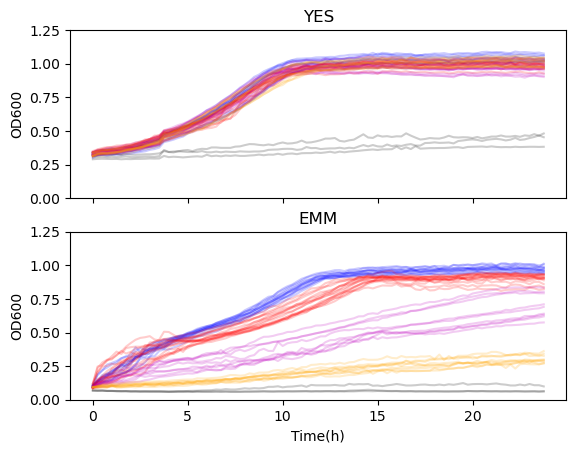

In [7]:
sample_map = pd.read_csv(base_dir + os.sep + '/' + fname_base + '_sample_map.csv')

fig, axarr = plt.subplots(2,1, sharex=True)

colormap = {'JB22': 'b', 
            'control': 'k',
            'srb10del': 'r', 
            'kgd2del': 'm',
            'tlg2del': 'orange' 
            }

for jj, media in enumerate(['YES','EMM']): 
    ax = axarr[jj]
    ax.set_title(media)
    if jj==1: 
        ax.set_xlabel('Time(h)')
    ax.set_ylabel('OD600')
    ax.set_ylim([0, 1.25])
    for strain in colormap.keys():
        sample_map_media_strain = sample_map[(sample_map['Media']==media) & (sample_map['Strain']==strain)]
        for row, col in zip(sample_map_media_strain['Row'], sample_map_media_strain['Column']):
            well = row + str(col).zfill(2)
            ax.plot(times, od_data.loc[well,:], c = colormap[strain], alpha = 0.2, label = strain)

A02
C06
E10
A04
C08
E12


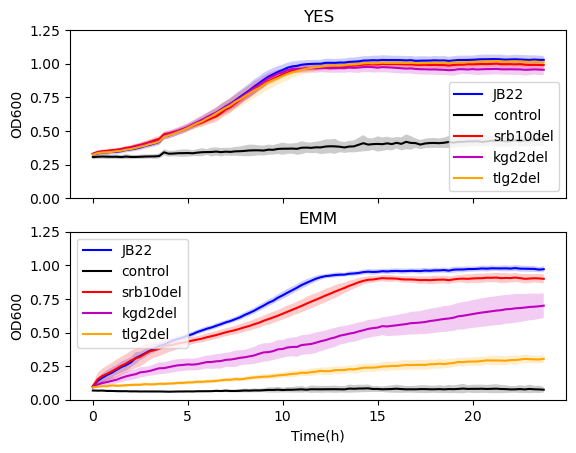

In [8]:
#Plot mean curves
fig, axarr = plt.subplots(2,1, sharex=True)

colormap = {'JB22': 'b', 
            'control': 'k',
            'srb10del': 'r', 
            'kgd2del': 'm',
            'tlg2del': 'orange' 
            }

for jj, media in enumerate(['YES','EMM']): 
    ax = axarr[jj]
    ax.set_title(media)
    if jj==1: 
        ax.set_xlabel('Time(h)')
    ax.set_ylabel('OD600')
    ax.set_ylim([0, 1.25])

    well_lists = dict(zip(colormap.keys(), [[] for jj in range(len(colormap.keys()))]))  #List to store well names for various conditions

    for strain in colormap.keys():
        sample_map_media_strain = sample_map[(sample_map['Media']==media) & (sample_map['Strain']==strain)]
        for row, col in zip(sample_map_media_strain['Row'], sample_map_media_strain['Column']):
            well = row + str(col).zfill(2)
            if strain=='control':
                print(well)
            well_lists[strain].append(well)      
            
    
        mean = od_data.loc[well_lists[strain],:].mean()
        std = od_data.loc[well_lists[strain],:].std()
        ax.plot(times, mean, c = colormap[strain], label = strain)
        ax.fill_between(times, mean - std, mean + std, facecolor=colormap[strain], alpha=0.2)
    ax.legend()

    



# #plot edge vs middle
# fig, axarr = plt.subplots(2,1, sharex=True)

# colormap = {'JB22': 'r', 
#             'JB22_edge': 'grey',
#             'Control': 'b', 
#             'Control_edge': 'k'
#             }

# for jj, media in enumerate(['YES','EMM']): 
#     ax = axarr[jj]
#     ax.set_title(media)
#     if jj==1: 
#         ax.set_xlabel('Time(h)')
#     ax.set_ylabel('OD600')
#     ax.set_ylim([0, 1.25])

#     well_lists = {'JB22': [], 
#             'JB22_edge': [],
#             'Control': [], 
#             'Control_edge': []
#             }

#     for strain in ['JB22', 'Control']:  
#         sample_map_media_strain = sample_map[(sample_map['Media']==media) & (sample_map['Strain']==strain)]
        
#         for row, col in zip(sample_map_media_strain['Row'], sample_map_media_strain['Column']):  # Extract wells 
#             if (row in {'A','H'}) | (col in {1,12}):  # Edge well
#                 well = row + str(col).zfill(2)          
#                 well_lists[strain + '_edge'].append(well)
                
#             else: 
#                 well = row + str(col).zfill(2)          
#                 well_lists[strain].append(well)
#                 #ax.plot(times, od_data.loc[well,:], c = colormap[strain], alpha = 0.2)
    
        
#         for edge in {'', '_edge'}: 
#             mean = od_data.loc[well_lists[strain + edge],:].mean()
#             std = od_data.loc[well_lists[strain + edge],:].std()
#             ax.plot(times, mean, c = colormap[strain + edge], label = strain + edge)
#             ax.fill_between(times, mean - std, mean + std, facecolor=colormap[strain + edge], alpha=0.2)
#         ax.legend()


In [ ]:
## 8 July Experiment

In [50]:
## 17 July Experiment

fname_base = '20250716_jb22_srb10_kgd2_tlg2'
skiprows_param = 9

#For these data downloaded temperature and humidity

od_data = pd.read_csv(base_dir + os.sep + fname_base + '.csv', skiprows=skiprows_param, index_col=0)
od_data = od_data.drop(columns = ['Content'])


#Identify which columns are Raw Data, Humidity, and Temperature
od_data.columns

raw_data_cols = []
humidity_cols = []
temp_cols = []

for jj, column in enumerate(od_data.columns):
    if "Raw Data" in column:
        raw_data_cols.append(jj)
    if "Humidity" in column:
        humidity_cols.append(jj)
    if "Temperature" in column: 
        temp_cols.append(jj)

raw_data = od_data.iloc[1:,raw_data_cols]
raw_data = raw_data.astype('float')

#Assume temperature and humidity have only one value - using the first row for that value
temps = list(od_data.iloc[1,temp_cols].astype('float'))
humidity = list(od_data.iloc[1,humidity_cols].astype('float'))

times_raw = list(od_data.iloc[0,0:len(raw_data_cols)])

times = []
for time in times_raw:
    timesp = time.split(' h ')
    hour = int(timesp[0])
    if timesp[1]=='': 
        min = 0
    else: 
        min = int(timesp[1].split(' min')[0])
    times.append(float(hour + min/60))

In [49]:
raw_data.astype('float')

,Raw Data (600),Raw Data (600).1,Raw Data (600).2,Raw Data (600).3,Raw Data (600).4,Raw Data (600).5,Raw Data (600).6,Raw Data (600).7,Raw Data (600).8,Raw Data (600).9,...,Raw Data (600).86,Raw Data (600).87,Raw Data (600).88,Raw Data (600).89,Raw Data (600).90,Raw Data (600).91,Raw Data (600).92,Raw Data (600).93,Raw Data (600).94,Raw Data (600).95
Well,,,,,,,,,,,,,,,,,,,,,
A01,0.577,0.549,0.549,0.551,0.557,0.560,0.565,0.573,0.576,0.587,...,1.194,1.196,1.195,1.199,1.195,1.202,1.195,1.198,1.197,1.195
A02,0.489,0.488,0.483,0.477,0.475,0.474,0.472,0.470,0.467,0.469,...,0.467,0.472,0.465,0.468,0.468,0.467,0.469,0.467,0.466,0.469
A03,0.165,0.298,0.316,0.350,0.373,0.412,0.412,0.430,0.428,0.446,...,1.064,1.070,1.070,1.068,1.071,1.072,1.075,1.071,1.071,1.074
A04,0.102,0.105,0.105,0.106,0.106,0.104,0.106,0.104,0.105,0.105,...,0.103,0.103,0.103,0.101,0.102,0.102,0.102,0.103,0.101,0.104
A05,0.485,0.483,0.479,0.477,0.480,0.476,0.479,0.478,0.479,0.481,...,1.085,1.101,1.103,1.099,1.107,1.098,1.106,1.099,1.096,1.105
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
H08,0.146,0.235,0.260,0.296,0.328,0.327,0.353,0.410,0.455,0.449,...,1.077,1.087,1.088,1.087,1.091,1.083,1.090,1.086,1.090,1.091
H09,0.505,0.499,0.501,0.507,0.507,0.508,0.509,0.512,0.513,0.521,...,1.185,1.195,1.199,1.194,1.202,1.194,1.202,1.194,1.191,1.200
H10,0.496,0.502,0.502,0.500,0.502,0.499,0.503,0.501,0.505,0.505,...,1.089,1.101,1.099,1.095,1.108,1.087,1.105,1.094,1.092,1.104


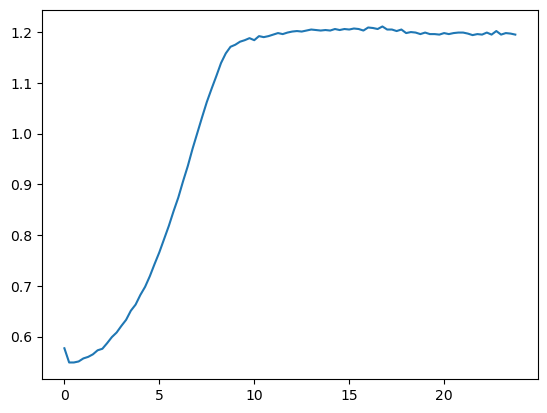

In [51]:
fig, ax = plt.subplots()

ax.plot(times, raw_data.loc['A01'])

In [54]:
#Plot entire 96 well plate: 

fig, axarr = plt.subplots(8,12, figsize = (120,80), sharey=True, sharex = True)
for jj, row in enumerate('ABCDEFGH'):
    for kk, col in enumerate(range(1,13)): 
        ax = axarr[jj,kk]
        well = row + str(col).zfill(2)
        a = times
        b = list(raw_data.loc[well,:])
        ax.plot(times, list(raw_data.loc[well,:]))
        ax.set_ylim(0,1.25)
        if col==1: 
            ax.set_ylabel(row)
        if row=='H': 
            ax.set_xlabel(str(col))




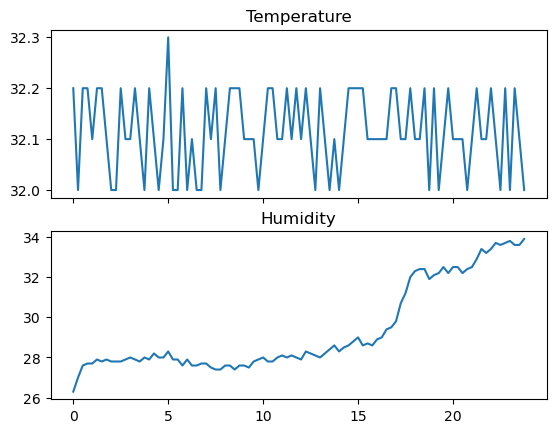

In [57]:
#Plot Temp and Humidity over Time

fig, axarr = plt.subplots(2,1, sharex=True)

plot_items = {'Temperature': temps, 
              'Humidity': humidity
              }

for jj, (title, data) in enumerate(plot_items.items()): 
    ax = axarr[jj]
    ax.plot(times, data)
    ax.set_title(title)

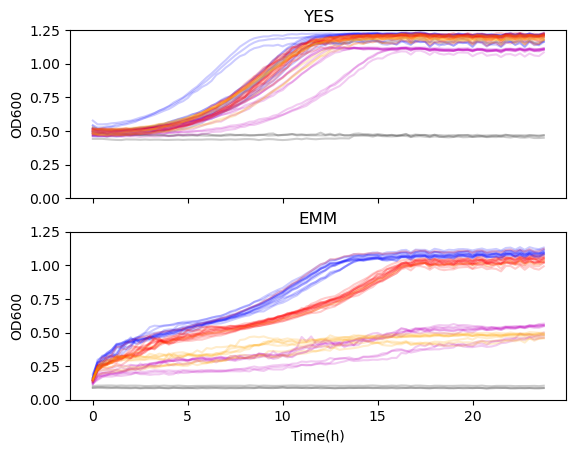

In [58]:
sample_map = pd.read_csv(base_dir + os.sep + '/' + fname_base + '_sample_map.csv')

fig, axarr = plt.subplots(2,1, sharex=True)

colormap = {'JB22': 'b', 
            'control': 'k',
            'srb10del': 'r', 
            'kgd2del': 'm',
            'tlg2del': 'orange' 
            }

for jj, media in enumerate(['YES','EMM']): 
    ax = axarr[jj]
    ax.set_title(media)
    if jj==1: 
        ax.set_xlabel('Time(h)')
    ax.set_ylabel('OD600')
    ax.set_ylim([0, 1.25])
    for strain in colormap.keys():
        sample_map_media_strain = sample_map[(sample_map['Media']==media) & (sample_map['Strain']==strain)]
        for row, col in zip(sample_map_media_strain['Row'], sample_map_media_strain['Column']):
            well = row + str(col).zfill(2)
            ax.plot(times, raw_data.loc[well,:], c = colormap[strain], alpha = 0.2, label = strain)

A02
C06
E10
A04
C08
E12


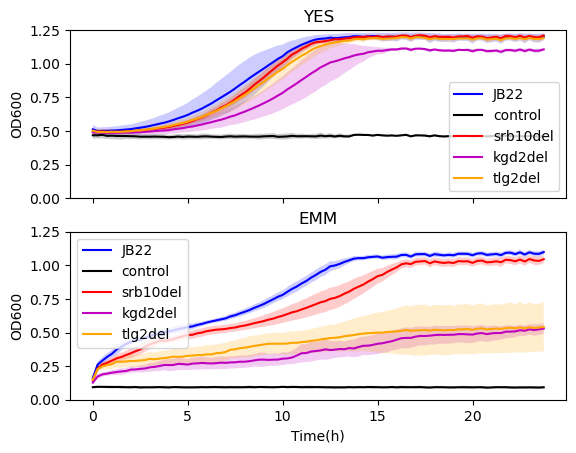

In [59]:


#Plot mean curves
fig, axarr = plt.subplots(2,1, sharex=True)

colormap = {'JB22': 'b', 
            'control': 'k',
            'srb10del': 'r', 
            'kgd2del': 'm',
            'tlg2del': 'orange' 
            }

for jj, media in enumerate(['YES','EMM']): 
    ax = axarr[jj]
    ax.set_title(media)
    if jj==1: 
        ax.set_xlabel('Time(h)')
    ax.set_ylabel('OD600')
    ax.set_ylim([0, 1.25])

    well_lists = dict(zip(colormap.keys(), [[] for jj in range(len(colormap.keys()))]))  #List to store well names for various conditions

    for strain in colormap.keys():
        sample_map_media_strain = sample_map[(sample_map['Media']==media) & (sample_map['Strain']==strain)]
        for row, col in zip(sample_map_media_strain['Row'], sample_map_media_strain['Column']):
            well = row + str(col).zfill(2)
            if strain=='control':
                print(well)
            well_lists[strain].append(well)      
            
    
        mean = raw_data.loc[well_lists[strain],:].mean()
        std = raw_data.loc[well_lists[strain],:].std()
        ax.plot(times, mean, c = colormap[strain], label = strain)
        ax.fill_between(times, mean - std, mean + std, facecolor=colormap[strain], alpha=0.2)
    ax.legend()

    


In [2]:
#For each experiment load the data 

exps = ['srb11_mus7_rpa12','srb10_kgd2_tlg2' ]


od_data = {}
times = {}
sample_map = {}


#Load data


for exp in exps: 

    if exp == 'srb11_mus7_rpa12': 

        fname_base = '20250604_jb22_srb11_mus7_rpa12' # 4 June Experiment
        skiprows_param = 10

        od_data_exp = pd.read_csv(base_dir + os.sep + fname_base + '.csv', skiprows=skiprows_param, index_col=0)
        od_data_exp = od_data_exp.drop(columns = ['Time'])

        od_data[exp] = od_data_exp

        times_raw = list(od_data_exp.columns)
    elif exp == 'srb10_kgd2_tlg2': ## 17 July Experiment
        fname_base = '20250716_jb22_srb10_kgd2_tlg2'
        skiprows_param = 9

        #For these data downloaded temperature and humidity
        od_data_exp = pd.read_csv(base_dir + os.sep + fname_base + '.csv', skiprows=skiprows_param, index_col=0)
        od_data_exp = od_data_exp.drop(columns = ['Content'])


        #Identify which columns are Raw Data, Humidity, and Temperature
        raw_data_cols = []
        humidity_cols = []
        temp_cols = []

        for jj, column in enumerate(od_data_exp.columns):
            if "Raw Data" in column:
                raw_data_cols.append(jj)
            if "Humidity" in column:
                humidity_cols.append(jj)
            if "Temperature" in column: 
                temp_cols.append(jj)

        raw_data = od_data_exp.iloc[1:,raw_data_cols]
        raw_data = raw_data.astype('float')

        od_data[exp] = raw_data

        #Assume temperature and humidity have only one value - using the first row for that value
        temps = list(od_data_exp.iloc[1,temp_cols].astype('float'))
        humidity = list(od_data_exp.iloc[1,humidity_cols].astype('float'))

        times_raw = list(od_data_exp.iloc[0,0:len(raw_data_cols)])

    times_exp = []
    for time in times_raw:
        timesp = time.split(' h ')
        hour = int(timesp[0])
        if timesp[1]=='': 
            min = 0
        else: 
            min = int(timesp[1].split(' min')[0])
        times_exp.append(float(hour + min/60))

    times[exp] = times_exp

    sample_map[exp] = pd.read_csv(base_dir + os.sep + '/' + fname_base + '_sample_map.csv')





In [6]:
od_data.keys()

dict_keys(['srb11_mus7_rpa12', 'srb10_kgd2_tlg2'])

KeyError: 'YES'

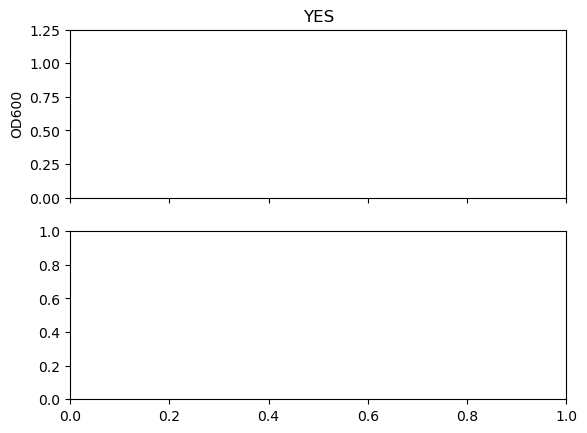

In [ ]:
# Normally would need to check if times vector was the same but it is in this case

assert times['srb11_mus7_rpa12'][-1] == times['srb10_kgd2_tlg2'][-1], 'time vectors do not match for experiment'
assert len(times['srb11_mus7_rpa12']) == len(times['srb10_kgd2_tlg2']), 'time vectors do not match for experiment'

strains = {'srb11_mus7_rpa12': ['JB22','control','srb11del','mus7del','rpa12del'], 
           'srb10_kgd2_tlg2': ['JB22','control','srb10del','kgd2del','tlg2del']}


well_lists = {}

for exp in exps: 
    sample_map_exp = sample_map[exp]
    #make well lists to identify strains 
    well_lists_exp = {}

    for jj, media in enumerate(['YES','EMM']): 


        well_lists_media = dict(zip(strains[exp], [[] for jj in range(len(strains[exp]))]))  #List to store well names for various conditions

        for strain in strains[exp]:
            sample_map_media_strain = sample_map_exp[(sample_map_exp['Media']==media) & (sample_map_exp['Strain']==strain)]
            for row, col in zip(sample_map_media_strain['Row'], sample_map_media_strain['Column']):
                well = row + str(col).zfill(2)
                # if strain=='control':
                #     print(well)
                well_lists_media[strain].append(well)      

        well_lists_exp[media] = well_lists_media

    well_lists[exp] = well_lists_exp


#Get baseline value for each media
blank_val = {}

for exp in exps: 
    blank_val_exp = {}
    sample_map_exp = sample_map[exp]
    for jj, media in enumerate(['YES','EMM']): 
        row = list(sample_map_exp[(sample_map_exp['Media']==media) & (sample_map_exp['Strain']=='control')]['Row'])[0]
        col = list(sample_map_exp[(sample_map_exp['Media']==media) & (sample_map_exp['Strain']=='control')]['Column'])[0]

        well = row + str(col).zfill(2)
        blank_val_exp[media] = od_data[exp].loc[well][1]  #Use 1 index as 0 index had an artifact because we didn't do the initial shake. 
    blank_val[exp] = blank_val_exp


normalized_data_by_strain = {}

#for each experiment, normalize each row of data and make a dictionary with a multi index indicating
# (strain, exp_rep) : data as a list

norm_data = {}

for exp in exps: 

    well_lists_exp = well_lists[exp]
    for media in ['YES','EMM']:
        
        norm_data_dict_media = {}
        well_lists_media = well_lists_exp[media]

        blank_val_exp_media = blank_val[exp][media]
        for strain in strains[exp]:
            wells = well_lists_media[strain]
            rep_no = 0    #note that this replicate number does not match the number from the experiment - it would be better to use that
            for well in wells:
                norm_data_dict_media[(strain,exp, rep_no)] = list(od_data[exp].loc[well,:]-blank_val_exp_media)
                rep_no = rep_no + 1

        # make that into a pandas dataframe
        norm_data_media = pd.DataFrame.from_dict(norm_data_dict_media, orient='index')
        norm_data_media.index = pd.MultiIndex.from_tuples(norm_data_media.index, names=['strain','exp','rep'])

        norm_data[media] = norm_data_media



# plot mean and std of the dataframe - maybe remove std

#strain name in original data: (color, display_name)

strains_to_plot ={'JB22': ('b',u'WT' ),
                  'control': ('g','media'),
                  'srb11del':('r',u'srb11Δ' ),
                  'srb10del':('m',u'srb10Δ' ),
                  'mus7del':('b',u'mus7Δ' ),
                  'rpa12del':('c',u'rpa12Δ' ),
                  'kgd2del':('y',u'kgd2Δ' ),
                  'tlg2del':('g',u'tlg2Δ' )
}

fig, axarr = plt.subplots(2,1, sharex=True)

for jj, media in enumerate(['YES','EMM']): 
    for strain, (color, label) in strains_to_plot.items():        
        ax = axarr[jj]
        ax.set_title(media)
        if jj==1: 
            ax.set_xlabel('Time(h)')
        ax.set_ylabel('OD600')
        ax.set_ylim([0, 1.25])

        #Plot mean curves    
        mean = norm_data[media].loc[strain].mean()
        std = norm_data[media].loc[strain].std()
        
        ax.plot(times, mean, c = color, label = label)
        ax.fill_between(times, mean - std, mean + std, facecolor=color, alpha=0.2)
        ax.legend()


In [21]:
norm_data.loc['JB22'].mean()

0     0.038833
1     0.104000
2     0.124208
3     0.143125
4     0.157833
        ...   
91    0.968083
92    0.977792
93    0.972667
94    0.974167
95    0.980292
Length: 96, dtype: float64